In [12]:
%pip install -r requirements.txt


Note: you may need to restart the kernel to use updated packages.


In [ ]:
# CÉLULA 1: Importação de Bibliotecas e Configuração
import cv2
import matplotlib.pyplot as plt
import os
import glob

# Configuração para melhorar a exibição dos gráficos no notebook
plt.rcParams['figure.figsize'] = (12, 6)
plt.style.use('dark_background') # Fica visualmente muito mais profissional no relatório

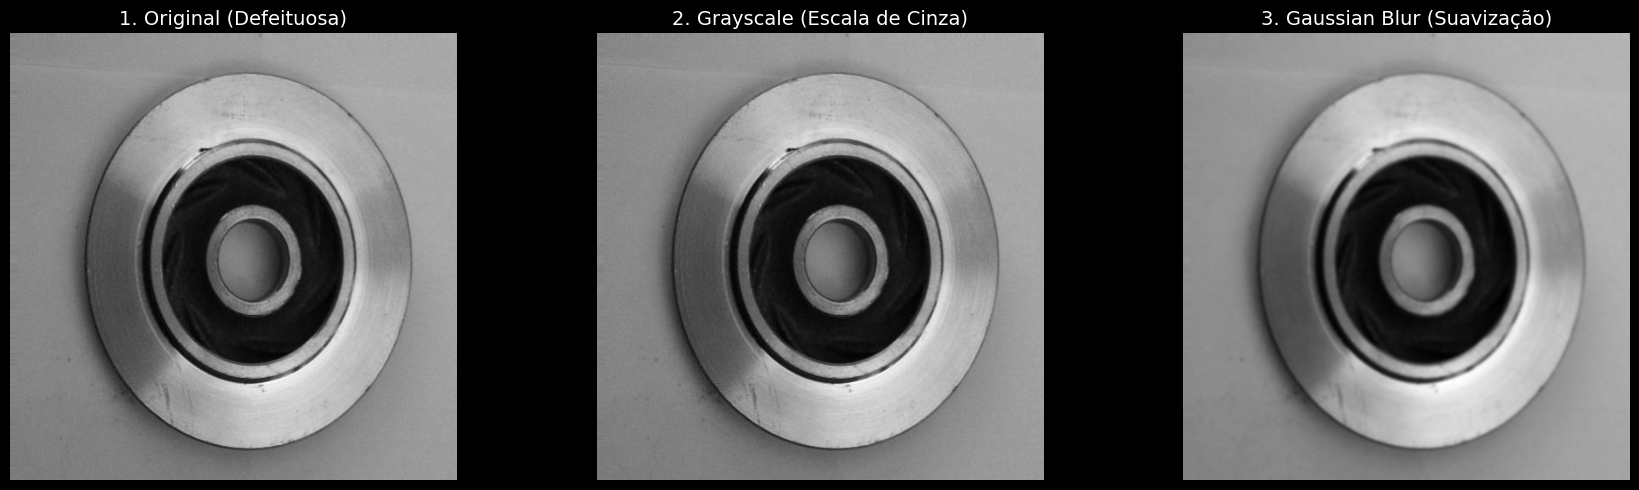

In [16]:
# CÉLULA 2: Função de Pré-processamento Clássico (Sprint 2)
caminho_amostra = glob.glob('casting_512x512/def_front/*.jpeg', recursive=True)

if not caminho_amostra:
    print("Erro: Nenhuma imagem encontrada. Verifique o caminho.")
else:
    imagem_path = caminho_amostra[0]
    
    img_original_bgr = cv2.imread(imagem_path)
    img_original_rgb = cv2.cvtColor(img_original_bgr, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_original_bgr, cv2.COLOR_BGR2GRAY)
    img_blur = cv2.GaussianBlur(img_gray, (7, 7), 0)
    
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    
    axs[0].imshow(img_original_rgb)
    axs[0].set_title("1. Original (Defeituosa)", fontsize=14)
    axs[0].axis('off')
    
    axs[1].imshow(img_gray, cmap='gray')
    axs[1].set_title("2. Grayscale (Escala de Cinza)", fontsize=14)
    axs[1].axis('off')
    
    axs[2].imshow(img_blur, cmap='gray')
    axs[2].set_title("3. Gaussian Blur (Suavização)", fontsize=14)
    axs[2].axis('off')
    
    plt.tight_layout()
    plt.show()

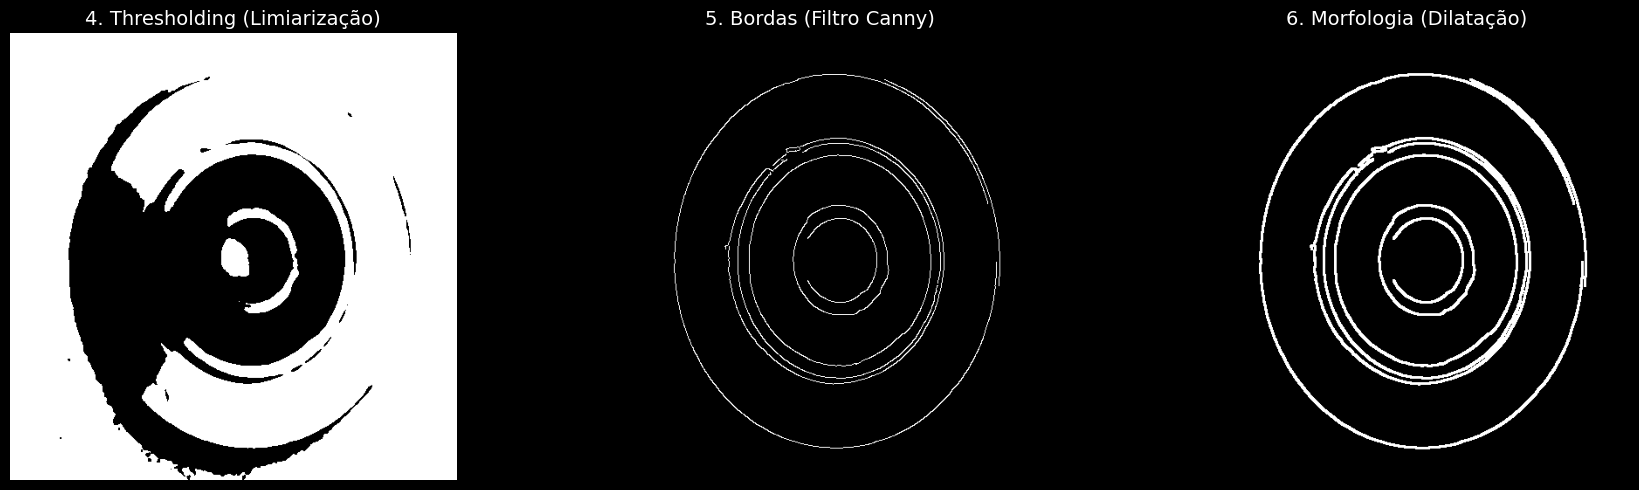

In [18]:
# CÉLULA 3: Destaque de Características (Sprint 3)

# 1. Limiarização (Thresholding): Converte a imagem suavizada em preto e branco absoluto
# Pixels mais escuros que 120 viram preto (0), mais claros viram branco (255)
_, img_thresh = cv2.threshold(img_blur, 120, 255, cv2.THRESH_BINARY)

# 2. Detecção de Bordas (Canny): Identifica quebras bruscas de intensidade (onde estão as ranhuras)
img_canny = cv2.Canny(img_blur, 50, 150)

# 3. Operações Morfológicas (Dilatação): Engrossa as bordas detectadas para evidenciar a falha
kernel_morfologico = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
img_dilatada = cv2.dilate(img_canny, kernel_morfologico, iterations=1)

# Plotando os resultados do Sprint 3
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].imshow(img_thresh, cmap='gray')
axs[0].set_title("4. Thresholding (Limiarização)", fontsize=14)
axs[0].axis('off')

axs[1].imshow(img_canny, cmap='gray')
axs[1].set_title("5. Bordas (Filtro Canny)", fontsize=14)
axs[1].axis('off')

axs[2].imshow(img_dilatada, cmap='gray')
axs[2].set_title("6. Morfologia (Dilatação)", fontsize=14)
axs[2].axis('off')

plt.tight_layout()
plt.show()

In [19]:
# CÉLULA 4: Ingestão de Dados e Data Augmentation (Sprint 4)
import tensorflow as tf
from tensorflow.keras import layers, Sequential

caminho_dataset = 'casting_512x512/'
tamanho_lote = 32 # Tamanho ideal para carregar lotes rapidamente na memória da GPU
dimensoes_imagem = (256, 256) # Redimensionamento para otimizar o treinamento da CNN

print("Construindo pipeline de Treinamento...")
dataset_treino = tf.keras.utils.image_dataset_from_directory(
    caminho_dataset,
    validation_split=0.2, # Separa 20% das imagens para testar se a IA está decorando ou aprendendo
    subset="training",
    seed=42, # Garante que a divisão seja sempre a mesma se rodarmos a célula de novo
    image_size=dimensoes_imagem,
    batch_size=tamanho_lote,
    color_mode="grayscale" 
)

print("\nConstruindo pipeline de Validação...")
dataset_validacao = tf.keras.utils.image_dataset_from_directory(
    caminho_dataset,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=dimensoes_imagem,
    batch_size=tamanho_lote,
    color_mode="grayscale"
)

# Pipeline Dinâmico de Data Augmentation 
# Isso "imuniza" a IA simulando que as peças estão passando tortas ou com iluminação diferente na esteira da fábrica
data_augmentation = Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomBrightness(factor=0.2)
], name="Camada_Augmentation")

print("\nIngestão automatizada e pipeline de Augmentation configurados com sucesso!")

I0000 00:00:1789417979.266825   43374 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789417979.306605   43374 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789417980.210959   43374 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Construindo pipeline de Treinamento...
Found 1300 files belonging to 2 classes.
Using 1040 files for training.


I0000 00:00:1789417981.803729   43374 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5633 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060, pci bus id: 0000:01:00.0, compute capability: 8.9



Construindo pipeline de Validação...
Found 1300 files belonging to 2 classes.
Using 260 files for validation.

Ingestão automatizada e pipeline de Augmentation configurados com sucesso!


In [20]:
# CÉLULA 5: A Arquitetura CNN e Treinamento (Sprint 5)

# Construção do Modelo Sequencial conforme exigido na rubrica
modelo_cnn = Sequential([
    # 1. Camada de Augmentation (aplica as distorções apenas no dataset de treino)
    data_augmentation,
    
    # 2. Normalização dos pixels (de 0-255 para 0-1) para a rede convergir mais rápido
    layers.Rescaling(1./255, input_shape=(256, 256, 1)),
    
    # 3. Bloco de Extração de Características 1 (Filtros de Convolução)
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # 4. Bloco de Extração de Características 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # 5. Transição Matricial (Achatar os dados para a rede neural clássica)
    layers.Flatten(),
    
    # 6. Decisão e Classificação Binária (Peça "OK" ou "Defeituosa")
    # A função sigmoid gera uma probabilidade final entre 0 e 1
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compilação com otimizador Adam e função de perda binária (exigência do critério 8)
modelo_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Resumo da Arquitetura:")
modelo_cnn.summary()

print("\nIniciando o Treinamento...")
# Execução do treinamento por 10 épocas
epocas = 10 
historico = modelo_cnn.fit(
    dataset_treino,
    validation_data=dataset_validacao,
    epochs=epocas
)

Resumo da Arquitetura:


/home/mirtilo/Vscode-projetos/.venv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Camada_Augmentation             │ ?                      │   0 (unbuilt) │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Iniciando o Treinamento...
Epoch 1/10


/home/mirtilo/Vscode-projetos/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1789418104.098960   52317 cuda_dnn.cc:461] Loaded cuDNN version 92600


33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.5683 - loss: 1.2827 - val_accuracy: 0.5731 - val_loss: 0.6736
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.6087 - loss: 0.6652 - val_accuracy: 0.5692 - val_loss: 0.6314
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.6462 - loss: 0.6258 - val_accuracy: 0.7423 - val_loss: 0.5954
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.6904 - loss: 0.5934 - val_accuracy: 0.7385 - val_loss: 0.5752
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.7010 - loss: 0.5759 - val_accuracy: 0.7500 - val_loss: 0.5638
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.6923 - loss: 0.5750 - val_accuracy: 0.7231 - val_loss: 0.5644
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.6952 - loss: 0.5863 - val_accuracy: 0.7231 - val_loss: 0.5732
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.7240 - loss: 0.5596 - val_accuracy: 0.7346 - val_loss: 0.

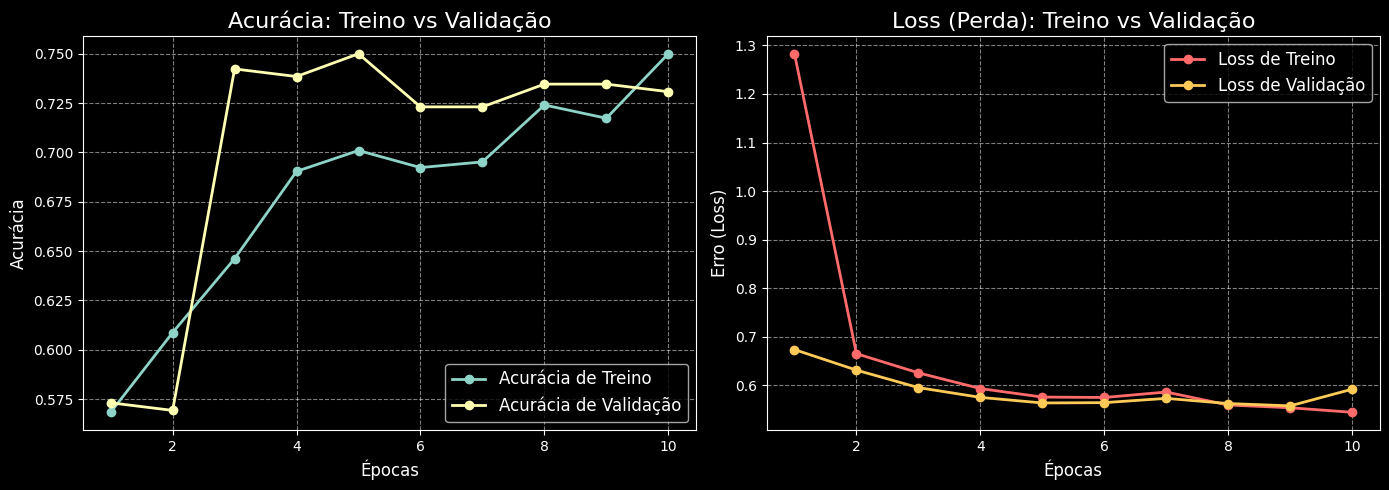

In [21]:
# CÉLULA 6: Auditoria Gráfica do Treinamento (Sprint 6)

# Extraindo os dados do histórico de treinamento
acc = historico.history['accuracy']
val_acc = historico.history['val_accuracy']
loss = historico.history['loss']
val_loss = historico.history['val_loss']
epocas_range = range(1, epocas + 1)

# Configurando a área de plotagem
plt.figure(figsize=(14, 5))

# Gráfico 1: Acurácia (O quanto a IA acertou)
plt.subplot(1, 2, 1)
plt.plot(epocas_range, acc, label='Acurácia de Treino', marker='o', linewidth=2)
plt.plot(epocas_range, val_acc, label='Acurácia de Validação', marker='o', linewidth=2)
plt.legend(loc='lower right', fontsize=12)
plt.title('Acurácia: Treino vs Validação', fontsize=16)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Gráfico 2: Loss/Perda (O quanto a IA errou)
plt.subplot(1, 2, 2)
plt.plot(epocas_range, loss, label='Loss de Treino', marker='o', color='#ff6b6b', linewidth=2)
plt.plot(epocas_range, val_loss, label='Loss de Validação', marker='o', color='#feca57', linewidth=2)
plt.legend(loc='upper right', fontsize=12)
plt.title('Loss (Perda): Treino vs Validação', fontsize=16)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Erro (Loss)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()